# 04 — Reproducing figure 1

4.1 Rebuild the paper's N = 2DTI model

4.2 Generate the exact reference curve

4.3 Implement one MSSE trajectory

4.4 Reproduce Figure 1(a)

4.5 Optimise x(t) and reproduce Figure 1(b)

4.6 Quantify the reproduction

4.1 Rebuild the paper’s two-spin DTI model

Set up the exact \(N=2\) dissipative transverse Ising model used in Figure 1, including the Hamiltonian, initial state, magnetisation operator, Lindblad operators, and paper parameters.

In [1]:
# Exercise 4.1 — Set up the N=2 dissipative transverse Ising model

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

from scipy.linalg import expm
from scipy.optimize import minimize_scalar


# ------------------------------------------------------------
# 1. Single-spin operators
# ------------------------------------------------------------

I = np.eye(2, dtype=complex)

sigma_x = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)

sigma_y = np.array([
    [0, -1j],
    [1j, 0]
], dtype=complex)

sigma_z = np.array([
    [1, 0],
    [0, -1]
], dtype=complex)

# |up> and |down>
up = np.array([1, 0], dtype=complex)
down = np.array([0, 1], dtype=complex)

# Lowering operator: |up> -> |down>
sigma_minus = np.array([
    [0, 0],
    [1, 0]
], dtype=complex)


# ------------------------------------------------------------
# 2. Two-spin operators
# ------------------------------------------------------------

sx1 = np.kron(sigma_x, I)
sx2 = np.kron(I, sigma_x)

sy1 = np.kron(sigma_y, I)
sy2 = np.kron(I, sigma_y)

sz1 = np.kron(sigma_z, I)
sz2 = np.kron(I, sigma_z)

sm1 = np.kron(sigma_minus, I)
sm2 = np.kron(I, sigma_minus)


# ------------------------------------------------------------
# 3. Paper parameters
# ------------------------------------------------------------

J = 1.0
Delta = 1.0
gamma = 0.5

# Paper: gamma * dt = 0.2
gamma_dt = 0.2
dt = gamma_dt / gamma

# Plot up to gamma*t = 4
gamma_t_max = 4.0
n_steps = int(round(gamma_t_max / gamma_dt))

times = np.arange(n_steps + 1) * dt
gamma_times = gamma * times


# ------------------------------------------------------------
# 4. DTI Hamiltonian — Eq. (8)
# ------------------------------------------------------------

H = (
    -J * (sz1 @ sz2)
    + Delta * (sx1 + sx2)
)


# ------------------------------------------------------------
# 5. Lindblad collapse operators
# ------------------------------------------------------------

L1 = np.sqrt(gamma) * sm1
L2 = np.sqrt(gamma) * sm2

collapse_ops = [L1, L2]


# ------------------------------------------------------------
# 6. Initial state: fully up
# ------------------------------------------------------------

psi0 = np.kron(up, up)
rho0 = np.outer(psi0, psi0.conj())


# ------------------------------------------------------------
# 7. Magnetisation operator
# ------------------------------------------------------------

Mz = (sz1 + sz2) / 2


# ------------------------------------------------------------
# 8. Basic validation
# ------------------------------------------------------------

initial_norm = np.vdot(psi0, psi0).real
initial_magnetisation = np.vdot(psi0, Mz @ psi0).real

print("PAPER PARAMETERS")
print("----------------")
print(f"J                  = {J}")
print(f"Delta              = {Delta}")
print(f"gamma              = {gamma}")
print(f"gamma * dt         = {gamma * dt}")
print(f"dt                 = {dt}")
print(f"Number of steps    = {n_steps}")
print(f"Maximum gamma*t    = {gamma_times[-1]}")

print("\nINITIAL STATE CHECKS")
print("--------------------")
print(f"State dimension    = {psi0.shape[0]}")
print(f"Initial norm       = {initial_norm}")
print(f"Initial <Mz>       = {initial_magnetisation}")

print("\nHAMILTONIAN")
print("-----------")
print(np.round(H, 3))

PAPER PARAMETERS
----------------
J                  = 1.0
Delta              = 1.0
gamma              = 0.5
gamma * dt         = 0.2
dt                 = 0.4
Number of steps    = 20
Maximum gamma*t    = 4.0

INITIAL STATE CHECKS
--------------------
State dimension    = 4
Initial norm       = 1.0
Initial <Mz>       = 1.0

HAMILTONIAN
-----------
[[-1.+0.j  1.+0.j  1.+0.j  0.+0.j]
 [ 1.+0.j  1.+0.j  0.+0.j  1.+0.j]
 [ 1.+0.j  0.+0.j  1.+0.j  1.+0.j]
 [ 0.+0.j  1.+0.j  1.+0.j -1.+0.j]]


4.2 Exact Lindblad reference solution

Solve the two-spin open-system dynamics directly with QuTiP and obtain the exact magnetisation curve that will serve as the benchmark for all later MSSE simulations.

EXACT LINDBLAD REFERENCE
------------------------
Number of dense points     = 401
Number of MSSE time points = 21
Initial magnetisation      = 1.000000
Final magnetisation        = -0.091839
Minimum magnetisation      = -0.375245
Maximum magnetisation      = 1.000000


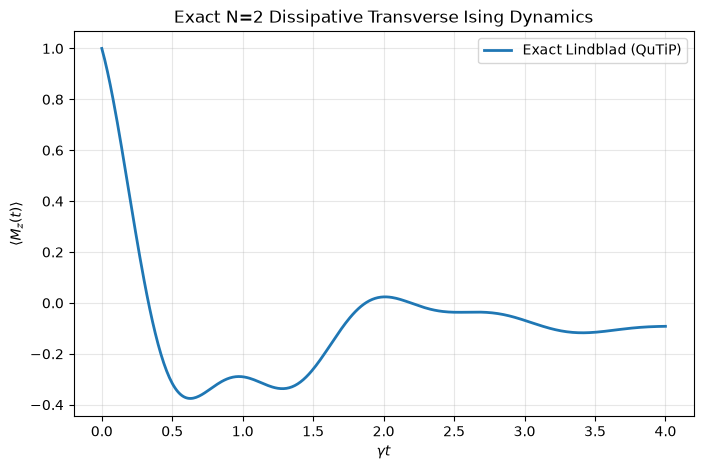

In [2]:
# Exercise 4.2 — Exact Lindblad reference solution with QuTiP

# ------------------------------------------------------------
# 1. Convert NumPy objects to QuTiP objects
# ------------------------------------------------------------

H_qt = qt.Qobj(
    H,
    dims=[[2, 2], [2, 2]]
)

rho0_qt = qt.Qobj(
    rho0,
    dims=[[2, 2], [2, 2]]
)

Mz_qt = qt.Qobj(
    Mz,
    dims=[[2, 2], [2, 2]]
)

collapse_ops_qt = [
    qt.Qobj(L, dims=[[2, 2], [2, 2]])
    for L in collapse_ops
]


# ------------------------------------------------------------
# 2. Dense time grid for the smooth exact reference curve
# ------------------------------------------------------------

exact_times = np.linspace(
    0,
    times[-1],
    401
)

exact_gamma_times = gamma * exact_times


# ------------------------------------------------------------
# 3. Solve the Lindblad master equation
# ------------------------------------------------------------

exact_result = qt.mesolve(
    H_qt,
    rho0_qt,
    exact_times,
    collapse_ops_qt,
    e_ops=[Mz_qt]
)

Mz_exact = np.real(exact_result.expect[0])


# ------------------------------------------------------------
# 4. Exact solution at the discrete MSSE time points
#    These values will be used later for numerical comparison.
# ------------------------------------------------------------

sample_result = qt.mesolve(
    H_qt,
    rho0_qt,
    times,
    collapse_ops_qt,
    e_ops=[Mz_qt]
)

Mz_exact_sampled = np.real(sample_result.expect[0])


# ------------------------------------------------------------
# 5. Validation
# ------------------------------------------------------------

print("EXACT LINDBLAD REFERENCE")
print("------------------------")
print(f"Number of dense points     = {len(exact_times)}")
print(f"Number of MSSE time points = {len(times)}")
print(f"Initial magnetisation      = {Mz_exact[0]:.6f}")
print(f"Final magnetisation        = {Mz_exact[-1]:.6f}")
print(f"Minimum magnetisation      = {np.min(Mz_exact):.6f}")
print(f"Maximum magnetisation      = {np.max(Mz_exact):.6f}")


# ------------------------------------------------------------
# 6. Plot the exact reference curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    exact_gamma_times,
    Mz_exact,
    linewidth=2,
    label="Exact Lindblad (QuTiP)"
)

plt.xlabel(r"$\gamma t$")
plt.ylabel(r"$\langle M_z(t)\rangle$")
plt.title("Exact N=2 Dissipative Transverse Ising Dynamics")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

4.3 Implement one MSSE trajectory

Implement the paper’s stochastic Schrödinger evolution for one trajectory, including jump probabilities, jump/no-jump evolution, normalisation, and the ordering parameter \(x\).

SINGLE MSSE TRAJECTORY
----------------------
x                     = 0.4906
Number of time steps  = 20
Number of jumps       = 4
Initial magnetisation = 1.000000
Final magnetisation   = 0.345604
Maximum norm error    = 4.44e-16

JUMP EVENTS
-----------
gamma*t = 1.00 : jump L2
gamma*t = 1.60 : jump L1
gamma*t = 2.80 : jump L1
gamma*t = 3.00 : jump L2


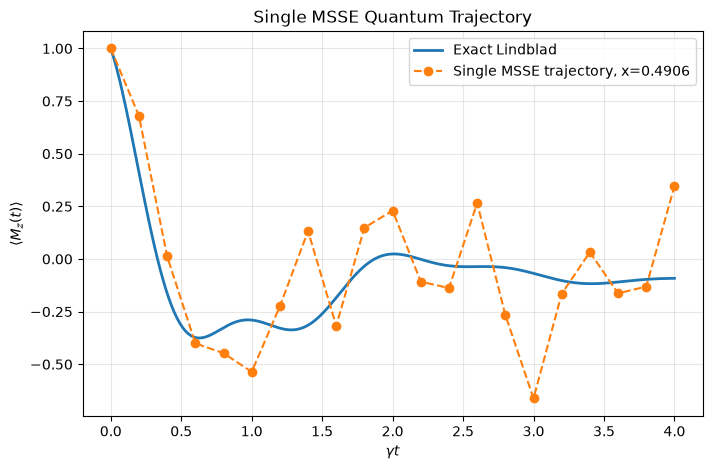

In [3]:
# Exercise 4.3 — Implement one MSSE quantum trajectory

# This exercise uses the variables already defined in 4.1 and 4.2:
# H, dt, times, gamma_times, collapse_ops, Mz, psi0,
# exact_gamma_times, Mz_exact


# ------------------------------------------------------------
# 1. Precompute useful operators
# ------------------------------------------------------------

I_sys = np.eye(H.shape[0], dtype=complex)

LdagL_ops = [
    L.conj().T @ L
    for L in collapse_ops
]

LdagL_sum = sum(LdagL_ops)


# ------------------------------------------------------------
# 2. One MSSE time step
# ------------------------------------------------------------

def msse_step(psi, x, rng):
    """
    Perform one stochastic MSSE time step.

    Returns
    -------
    psi_next : ndarray
        Normalised state after the time step.

    event : str
        'no jump', 'jump L1', or 'jump L2'.

    jump_probs : ndarray
        Probability of each possible jump during this step.

    p_no_jump : float
        Probability of no jump.
    """

    # --------------------------------------------------------
    # A. Hamiltonian evolution BEFORE the dissipative step
    #
    #       |phi> = exp(-i x H dt) |psi>
    # --------------------------------------------------------

    U_before = expm(-1j * x * H * dt)

    phi = U_before @ psi


    # --------------------------------------------------------
    # B. Calculate jump rates
    #
    #   <L†L>
    # --------------------------------------------------------

    jump_rates = np.array([
        np.real(np.vdot(phi, LdagL @ phi))
        for LdagL in LdagL_ops
    ])


    # --------------------------------------------------------
    # C. Eq. (3): jump probabilities
    #
    #   P_jump,l = <L_l† L_l> dt
    # --------------------------------------------------------

    jump_probs = jump_rates * dt

    p_total_jump = np.sum(jump_probs)
    p_no_jump = 1.0 - p_total_jump


    # Safety check: dt must be sufficiently small
    if p_total_jump > 1.0 + 1e-12:
        raise ValueError(
            f"Total jump probability = {p_total_jump:.4f} > 1. "
            "Reduce dt."
        )

    p_no_jump = max(p_no_jump, 0.0)


    # --------------------------------------------------------
    # D. Randomly decide whether a jump occurs
    # --------------------------------------------------------

    r = rng.random()

    if r < p_total_jump:

        # ----------------------------------------------------
        # JUMP BRANCH
        #
        # Choose which Lindblad operator caused the jump.
        # ----------------------------------------------------

        if p_total_jump > 0:
            conditional_probs = jump_probs / p_total_jump

            jump_index = rng.choice(
                len(collapse_ops),
                p=conditional_probs
            )
        else:
            jump_index = 0

        L = collapse_ops[jump_index]

        psi_branch = L @ phi

        event = f"jump L{jump_index + 1}"


    else:

        # ----------------------------------------------------
        # NO-JUMP BRANCH
        #
        # Eq. (5):
        #
        #   (I - 1/2 sum L†L dt) |phi>
        # ----------------------------------------------------

        no_jump_operator = (
            I_sys
            - 0.5 * LdagL_sum * dt
        )

        psi_branch = no_jump_operator @ phi

        event = "no jump"


    # --------------------------------------------------------
    # E. Normalise the conditional state
    #
    # A trajectory must remain a valid pure quantum state.
    # Eq. (5) is a finite-dt approximation, so we explicitly
    # normalise the selected branch numerically.
    # --------------------------------------------------------

    norm = np.linalg.norm(psi_branch)

    if norm < 1e-14:
        raise ValueError("Trajectory state has zero norm.")

    psi_branch = psi_branch / norm


    # --------------------------------------------------------
    # F. Hamiltonian evolution AFTER the dissipative step
    #
    #       exp[-i(1-x)Hdt]
    # --------------------------------------------------------

    U_after = expm(
        -1j * (1.0 - x) * H * dt
    )

    psi_next = U_after @ psi_branch


    # Numerical safety normalisation
    psi_next = psi_next / np.linalg.norm(psi_next)


    return psi_next, event, jump_probs, p_no_jump


# ------------------------------------------------------------
# 3. Run one complete trajectory
# ------------------------------------------------------------

x_test = 0.4906

# Fixed seed makes the example reproducible
rng = np.random.default_rng(42)

psi = psi0.copy()

trajectory_mz = [
    np.real(np.vdot(psi, Mz @ psi))
]

trajectory_norm = [
    np.vdot(psi, psi).real
]

event_log = ["initial state"]
probability_log = []


for step in range(len(times) - 1):

    psi, event, jump_probs, p_no_jump = msse_step(
        psi,
        x_test,
        rng
    )

    # Magnetisation
    mz = np.real(
        np.vdot(psi, Mz @ psi)
    )

    trajectory_mz.append(mz)

    # Norm check
    trajectory_norm.append(
        np.vdot(psi, psi).real
    )

    # Store event
    event_log.append(event)

    # Store probabilities used during the step
    probability_log.append({
        "step": step + 1,
        "gamma_t": gamma_times[step + 1],
        "P_jump_L1": jump_probs[0],
        "P_jump_L2": jump_probs[1],
        "P_no_jump": p_no_jump,
        "event": event
    })


trajectory_mz = np.array(trajectory_mz)
trajectory_norm = np.array(trajectory_norm)


# ------------------------------------------------------------
# 4. Print trajectory information
# ------------------------------------------------------------

number_of_jumps = sum(
    event.startswith("jump")
    for event in event_log
)

print("SINGLE MSSE TRAJECTORY")
print("----------------------")
print(f"x                     = {x_test}")
print(f"Number of time steps  = {len(times) - 1}")
print(f"Number of jumps       = {number_of_jumps}")
print(f"Initial magnetisation = {trajectory_mz[0]:.6f}")
print(f"Final magnetisation   = {trajectory_mz[-1]:.6f}")
print(
    f"Maximum norm error    = "
    f"{np.max(np.abs(trajectory_norm - 1)):.2e}"
)


# ------------------------------------------------------------
# 5. Show the jump history
# ------------------------------------------------------------

print("\nJUMP EVENTS")
print("-----------")

for i, event in enumerate(event_log):

    if event.startswith("jump"):
        print(
            f"gamma*t = {gamma_times[i]:.2f} : {event}"
        )


# ------------------------------------------------------------
# 6. Plot one trajectory against the exact Lindblad curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    exact_gamma_times,
    Mz_exact,
    linewidth=2,
    label="Exact Lindblad"
)

plt.plot(
    gamma_times,
    trajectory_mz,
    marker="o",
    linestyle="--",
    label=f"Single MSSE trajectory, x={x_test}"
)

plt.xlabel(r"$\gamma t$")
plt.ylabel(r"$\langle M_z(t)\rangle$")
plt.title("Single MSSE Quantum Trajectory")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

4.4 Reproduce Figure 1(a): fixed x

Average many MSSE trajectories for \(x=0\), \(x=1\), and \(x=0.4906\), then compare their magnetisation dynamics with the exact Lindblad solution to show how operator ordering affects accuracy.

Running x = 0.0 ...
Running x = 1.0 ...
Running x = 0.4906 ...

All ensembles complete.

FIXED-x RESULTS
---------------
x = 0.0000 | RMSE = 0.090643 | Mean jumps = 4.058
x = 1.0000 | RMSE = 0.099840 | Mean jumps = 3.924
x = 0.4906 | RMSE = 0.025819 | Mean jumps = 4.043


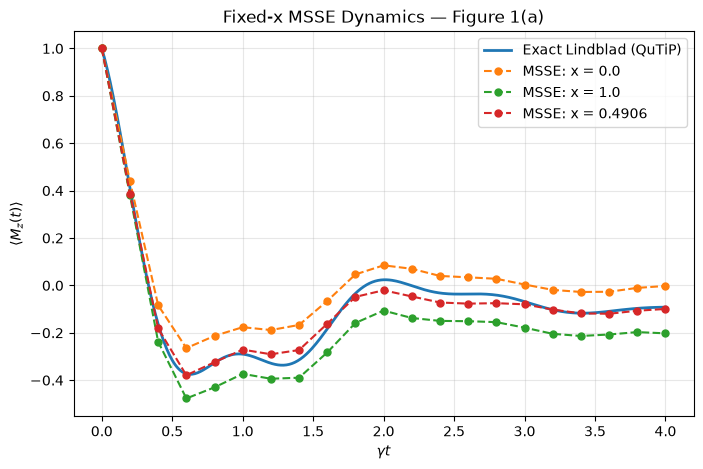

In [4]:
# Exercise 4.4 — Reproduce Figure 1(a) using fixed x values

# We now average many independent stochastic trajectories.
# One trajectory is random, but the ensemble average should
# approach the open-system magnetisation predicted by the MSSE.


# ------------------------------------------------------------
# 1. Function to run an ensemble of MSSE trajectories
# ------------------------------------------------------------

def run_msse_ensemble(x, n_trajectories=3000, seed=1234):
    """
    Run many independent MSSE trajectories for a fixed x
    and return the ensemble-averaged magnetisation.

    Parameters
    ----------
    x : float
        Hamiltonian/dissipation ordering parameter.

    n_trajectories : int
        Number of stochastic trajectories.

    seed : int
        Random seed for reproducibility.

    Returns
    -------
    mean_mz : ndarray
        Ensemble-averaged magnetisation at each time.

    sem_mz : ndarray
        Standard error of the mean magnetisation.

    mean_jumps : float
        Average number of jumps per trajectory.
    """

    rng = np.random.default_rng(seed)

    # --------------------------------------------------------
    # Precompute operators that are identical for every
    # trajectory with this value of x.
    # --------------------------------------------------------

    U_before = expm(
        -1j * x * H * dt
    )

    U_after = expm(
        -1j * (1.0 - x) * H * dt
    )

    no_jump_operator = (
        I_sys
        - 0.5 * LdagL_sum * dt
    )


    # --------------------------------------------------------
    # Accumulators
    # --------------------------------------------------------

    mz_sum = np.zeros(len(times))
    mz_squared_sum = np.zeros(len(times))

    total_jumps = 0


    # --------------------------------------------------------
    # Run independent trajectories
    # --------------------------------------------------------

    for trajectory in range(n_trajectories):

        psi = psi0.copy()

        mz_values = np.zeros(len(times))

        # Initial magnetisation
        mz_values[0] = np.real(
            np.vdot(psi, Mz @ psi)
        )

        trajectory_jumps = 0


        # ----------------------------------------------------
        # Time evolution
        # ----------------------------------------------------

        for step in range(1, len(times)):

            # A. Hamiltonian evolution before dissipation
            phi = U_before @ psi


            # ------------------------------------------------
            # B. Jump probabilities
            #
            # P_l = <L_l† L_l> dt
            # ------------------------------------------------

            jump_rates = np.array([
                max(
                    0.0,
                    np.real(
                        np.vdot(phi, LdagL @ phi)
                    )
                )
                for LdagL in LdagL_ops
            ])

            jump_probs = jump_rates * dt

            p_total_jump = np.sum(jump_probs)


            if p_total_jump > 1.0 + 1e-12:
                raise ValueError(
                    f"Total jump probability "
                    f"{p_total_jump:.4f} > 1."
                )


            # ------------------------------------------------
            # C. Choose jump or no-jump branch
            # ------------------------------------------------

            r = rng.random()

            cumulative = 0.0
            jump_index = None

            for j, p_jump in enumerate(jump_probs):

                cumulative += p_jump

                if r < cumulative:
                    jump_index = j
                    break


            # ------------------------------------------------
            # D. Apply selected branch
            # ------------------------------------------------

            if jump_index is not None:

                # Quantum jump
                psi_branch = (
                    collapse_ops[jump_index] @ phi
                )

                trajectory_jumps += 1

            else:

                # No-jump evolution
                psi_branch = (
                    no_jump_operator @ phi
                )


            # ------------------------------------------------
            # E. Normalise conditional state
            # ------------------------------------------------

            norm = np.linalg.norm(psi_branch)

            if norm < 1e-14:
                raise ValueError(
                    "Trajectory state has zero norm."
                )

            psi_branch = psi_branch / norm


            # ------------------------------------------------
            # F. Remaining Hamiltonian evolution
            # ------------------------------------------------

            psi = U_after @ psi_branch

            psi = psi / np.linalg.norm(psi)


            # ------------------------------------------------
            # G. Measure magnetisation
            # ------------------------------------------------

            mz_values[step] = np.real(
                np.vdot(psi, Mz @ psi)
            )


        # ----------------------------------------------------
        # Add this trajectory to ensemble statistics
        # ----------------------------------------------------

        mz_sum += mz_values

        mz_squared_sum += mz_values**2

        total_jumps += trajectory_jumps


    # --------------------------------------------------------
    # 2. Ensemble average
    # --------------------------------------------------------

    mean_mz = (
        mz_sum / n_trajectories
    )


    # --------------------------------------------------------
    # 3. Standard error of the mean
    # --------------------------------------------------------

    variance = (
        mz_squared_sum
        - n_trajectories * mean_mz**2
    ) / (n_trajectories - 1)

    variance = np.maximum(
        variance,
        0.0
    )

    sem_mz = np.sqrt(
        variance / n_trajectories
    )


    mean_jumps = (
        total_jumps / n_trajectories
    )


    return mean_mz, sem_mz, mean_jumps


# ------------------------------------------------------------
# 4. Run the three fixed-x simulations from Figure 1(a)
# ------------------------------------------------------------

n_trajectories = 3000

fixed_x_values = [
    0.0,
    1.0,
    0.4906
]

results_fixed_x = {}


for i, x in enumerate(fixed_x_values):

    print(
        f"Running x = {x} ..."
    )

    mean_mz, sem_mz, mean_jumps = (
        run_msse_ensemble(
            x=x,
            n_trajectories=n_trajectories,
            seed=1234 + i
        )
    )

    results_fixed_x[x] = {
        "mean": mean_mz,
        "sem": sem_mz,
        "mean_jumps": mean_jumps
    }


print("\nAll ensembles complete.")


# ------------------------------------------------------------
# 5. Simple comparison with exact Lindblad solution
# ------------------------------------------------------------

print("\nFIXED-x RESULTS")
print("---------------")

for x in fixed_x_values:

    mean_mz = results_fixed_x[x]["mean"]

    rmse = np.sqrt(
        np.mean(
            (mean_mz - Mz_exact_sampled)**2
        )
    )

    print(
        f"x = {x:6.4f} | "
        f"RMSE = {rmse:.6f} | "
        f"Mean jumps = "
        f"{results_fixed_x[x]['mean_jumps']:.3f}"
    )


# ------------------------------------------------------------
# 6. Reproduce the structure of Figure 1(a)
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))


# Exact Lindblad reference
plt.plot(
    exact_gamma_times,
    Mz_exact,
    linewidth=2,
    label="Exact Lindblad (QuTiP)"
)


# Fixed-x MSSE results
for x in fixed_x_values:

    plt.plot(
        gamma_times,
        results_fixed_x[x]["mean"],
        marker="o",
        linestyle="--",
        markersize=5,
        label=f"MSSE: x = {x}"
    )


plt.xlabel(r"$\gamma t$")
plt.ylabel(r"$\langle M_z(t)\rangle$")

plt.title(
    "Fixed-x MSSE Dynamics — Figure 1(a)"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

4.5 Optimise x(t) and reproduce Figure 1(b)

Implement the paper’s leading-error expression, determine the optimal \(x(t)\) sequence, and test whether the optimised MSSE evolution follows the exact dynamics more accurately than the fixed-\(x\) methods.

INITIAL OPTIMISATION CHECK
--------------------------
Calculated x(0) = 0.490569
Paper value      ≈ 0.4906

Running optimised MSSE ensemble...
Optimised ensemble complete.

OPTIMISATION RESULTS
--------------------
x(0)                  = 0.490569
Optimised RMSE        = 0.023203
Mean jumps/trajectory = 3.997

FIXED-x COMPARISON
------------------
x = 0.0000 | RMSE = 0.090643
x = 1.0000 | RMSE = 0.099840
x = 0.4906 | RMSE = 0.025819


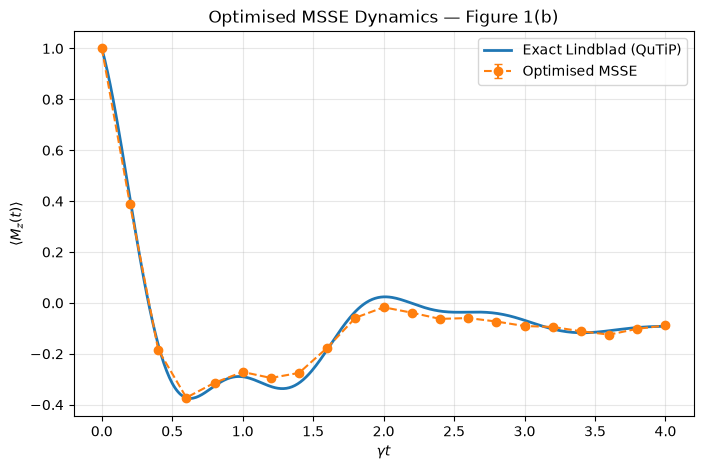

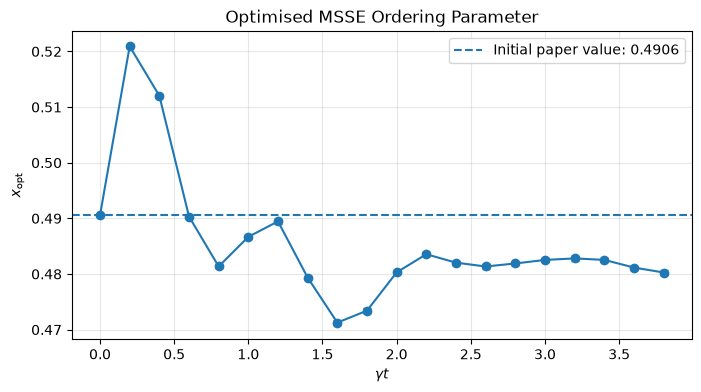

In [5]:
# Exercise 4.5 — Optimise x(t) using Eq. (7)

# This exercise uses variables already defined in 4.1–4.4:
# H, dt, times, gamma_times, psi0, Mz,
# collapse_ops, LdagL_ops, LdagL_sum, I_sys,
# exact_gamma_times, Mz_exact, Mz_exact_sampled


# ------------------------------------------------------------
# 1. Precompute operators appearing in Eq. (7)
# ------------------------------------------------------------

H_squared = H @ H

commutator_sum = sum(
    H @ LdagL - LdagL @ H
    for LdagL in LdagL_ops
)


# ------------------------------------------------------------
# 2. Eq. (7): leading MSSE error
# ------------------------------------------------------------

def msse_error_eq7(psi, x):
    """
    Squared norm of the leading-order MSSE error
    from Eq. (7) of the paper.
    """

    # Sum_l <L_l^\dagger L_l>
    expectation_sum = sum(
        np.real(
            np.vdot(
                psi,
                LdagL @ psi
            )
        )
        for LdagL in LdagL_ops
    )

    # Sum_l (L_l^\dagger L_l - <L_l^\dagger L_l>)
    centered_dissipation = (
        LdagL_sum
        - expectation_sum * I_sys
    )

    # Operator inside Eq. (7)
    error_operator = (
        -0.5
        * (1 - 2*x + 2*x**2)
        * H_squared

        + 0.5j
        * H
        @ centered_dissipation

        - 0.5j
        * x
        * commutator_sum
    )

    error_vector = (
        error_operator @ psi
    )

    error_norm_squared = np.real(
        np.vdot(
            error_vector,
            error_vector
        )
    )

    return float(error_norm_squared)


# ------------------------------------------------------------
# 3. Find the optimal x for the current state
# ------------------------------------------------------------

def find_optimal_x(psi):
    """
    Minimise Eq. (7) over 0 <= x <= 1.
    """

    result = minimize_scalar(
        lambda x: msse_error_eq7(
            psi,
            x
        ),
        bounds=(0.0, 1.0),
        method="bounded",
        options={
            "xatol": 1e-10
        }
    )

    return result.x


# ------------------------------------------------------------
# 4. Check the initial optimal value
# ------------------------------------------------------------

x_initial = find_optimal_x(
    psi0
)

print("INITIAL OPTIMISATION CHECK")
print("--------------------------")
print(
    f"Calculated x(0) = "
    f"{x_initial:.6f}"
)
print(
    "Paper value      ≈ "
    "0.4906"
)


# ------------------------------------------------------------
# 5. Run an ensemble using optimised x(t)
# ------------------------------------------------------------

def run_optimised_msse_ensemble(
    n_trajectories=3000,
    seed=2026
):
    """
    Run many MSSE trajectories.

    At every time step, x is obtained by minimising
    Eq. (7) for the current pure state.
    """

    rng = np.random.default_rng(seed)

    # Ensemble statistics for magnetisation
    mz_sum = np.zeros(
        len(times)
    )

    mz_squared_sum = np.zeros(
        len(times)
    )

    # Statistics for x(t)
    x_sum = np.zeros(
        len(times) - 1
    )

    x_squared_sum = np.zeros(
        len(times) - 1
    )

    total_jumps = 0


    # --------------------------------------------------------
    # Run trajectories
    # --------------------------------------------------------

    for trajectory in range(
        n_trajectories
    ):

        psi = psi0.copy()

        mz_values = np.zeros(
            len(times)
        )

        mz_values[0] = np.real(
            np.vdot(
                psi,
                Mz @ psi
            )
        )

        trajectory_jumps = 0


        # ----------------------------------------------------
        # Time evolution
        # ----------------------------------------------------

        for step in range(
            1,
            len(times)
        ):

            # -----------------------------------------------
            # A. Find optimal x from Eq. (7)
            # -----------------------------------------------

            x_opt = find_optimal_x(
                psi
            )

            x_sum[
                step - 1
            ] += x_opt

            x_squared_sum[
                step - 1
            ] += x_opt**2


            # -----------------------------------------------
            # B. Split Hamiltonian evolution
            # -----------------------------------------------

            U_before = expm(
                -1j
                * x_opt
                * H
                * dt
            )

            U_after = expm(
                -1j
                * (1.0 - x_opt)
                * H
                * dt
            )

            phi = (
                U_before @ psi
            )


            # -----------------------------------------------
            # C. Jump probabilities
            # -----------------------------------------------

            jump_rates = np.array([
                max(
                    0.0,
                    np.real(
                        np.vdot(
                            phi,
                            LdagL @ phi
                        )
                    )
                )
                for LdagL
                in LdagL_ops
            ])

            jump_probs = (
                jump_rates * dt
            )

            p_total_jump = np.sum(
                jump_probs
            )

            if (
                p_total_jump
                > 1.0 + 1e-12
            ):
                raise ValueError(
                    "Total jump probability "
                    f"{p_total_jump:.4f} > 1."
                )


            # -----------------------------------------------
            # D. Choose jump or no-jump branch
            # -----------------------------------------------

            r = rng.random()

            cumulative = 0.0
            jump_index = None

            for j, p_jump in enumerate(
                jump_probs
            ):

                cumulative += p_jump

                if r < cumulative:
                    jump_index = j
                    break


            # -----------------------------------------------
            # E. Apply selected branch
            # -----------------------------------------------

            if jump_index is not None:

                psi_branch = (
                    collapse_ops[
                        jump_index
                    ]
                    @ phi
                )

                trajectory_jumps += 1

            else:

                no_jump_operator = (
                    I_sys
                    - 0.5
                    * LdagL_sum
                    * dt
                )

                psi_branch = (
                    no_jump_operator
                    @ phi
                )


            # -----------------------------------------------
            # F. Normalise
            # -----------------------------------------------

            branch_norm = (
                np.linalg.norm(
                    psi_branch
                )
            )

            if branch_norm < 1e-14:
                raise ValueError(
                    "Trajectory state has "
                    "zero norm."
                )

            psi_branch = (
                psi_branch
                / branch_norm
            )


            # -----------------------------------------------
            # G. Remaining Hamiltonian evolution
            # -----------------------------------------------

            psi = (
                U_after
                @ psi_branch
            )

            psi = (
                psi
                / np.linalg.norm(psi)
            )


            # -----------------------------------------------
            # H. Magnetisation
            # -----------------------------------------------

            mz_values[step] = np.real(
                np.vdot(
                    psi,
                    Mz @ psi
                )
            )


        # ----------------------------------------------------
        # Add trajectory to ensemble statistics
        # ----------------------------------------------------

        mz_sum += mz_values

        mz_squared_sum += (
            mz_values**2
        )

        total_jumps += (
            trajectory_jumps
        )


    # --------------------------------------------------------
    # 6. Ensemble averages
    # --------------------------------------------------------

    mean_mz = (
        mz_sum
        / n_trajectories
    )


    # Magnetisation standard error
    variance_mz = (
        mz_squared_sum
        - n_trajectories
        * mean_mz**2
    ) / (
        n_trajectories - 1
    )

    variance_mz = np.maximum(
        variance_mz,
        0.0
    )

    sem_mz = np.sqrt(
        variance_mz
        / n_trajectories
    )


    # Mean x(t)
    mean_x = (
        x_sum
        / n_trajectories
    )


    variance_x = (
        x_squared_sum
        - n_trajectories
        * mean_x**2
    ) / (
        n_trajectories - 1
    )

    variance_x = np.maximum(
        variance_x,
        0.0
    )

    sem_x = np.sqrt(
        variance_x
        / n_trajectories
    )


    mean_jumps = (
        total_jumps
        / n_trajectories
    )


    return (
        mean_mz,
        sem_mz,
        mean_x,
        sem_x,
        mean_jumps
    )


# ------------------------------------------------------------
# 7. Run the optimised simulation
# ------------------------------------------------------------

n_trajectories_opt = 3000

print(
    "\nRunning optimised MSSE ensemble..."
)

(
    Mz_optimised,
    Mz_optimised_sem,
    x_mean,
    x_sem,
    mean_jumps_optimised
) = run_optimised_msse_ensemble(
    n_trajectories=n_trajectories_opt,
    seed=2026
)

print(
    "Optimised ensemble complete."
)


# ------------------------------------------------------------
# 8. Compare errors with fixed-x simulations
# ------------------------------------------------------------

rmse_optimised = np.sqrt(
    np.mean(
        (
            Mz_optimised
            - Mz_exact_sampled
        )**2
    )
)

print(
    "\nOPTIMISATION RESULTS"
)
print(
    "--------------------"
)

print(
    f"x(0)                  = "
    f"{x_initial:.6f}"
)

print(
    f"Optimised RMSE        = "
    f"{rmse_optimised:.6f}"
)

print(
    f"Mean jumps/trajectory = "
    f"{mean_jumps_optimised:.3f}"
)

print(
    "\nFIXED-x COMPARISON"
)
print(
    "------------------"
)

for x in fixed_x_values:

    fixed_mean = (
        results_fixed_x[x]["mean"]
    )

    fixed_rmse = np.sqrt(
        np.mean(
            (
                fixed_mean
                - Mz_exact_sampled
            )**2
        )
    )

    print(
        f"x = {x:6.4f} | "
        f"RMSE = {fixed_rmse:.6f}"
    )


# ------------------------------------------------------------
# 9. Plot Figure 1(b)-style comparison
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    exact_gamma_times,
    Mz_exact,
    linewidth=2,
    label="Exact Lindblad (QuTiP)"
)

plt.errorbar(
    gamma_times,
    Mz_optimised,
    yerr=Mz_optimised_sem,
    marker="o",
    linestyle="--",
    capsize=3,
    label="Optimised MSSE"
)

plt.xlabel(
    r"$\gamma t$"
)

plt.ylabel(
    r"$\langle M_z(t)\rangle$"
)

plt.title(
    "Optimised MSSE Dynamics — Figure 1(b)"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ------------------------------------------------------------
# 10. Plot the mean optimised x(t) sequence
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 4)
)

plt.errorbar(
    gamma_times[:-1],
    x_mean,
    yerr=x_sem,
    marker="o",
    capsize=3
)

plt.axhline(
    0.4906,
    linestyle="--",
    label="Initial paper value: 0.4906"
)

plt.xlabel(
    r"$\gamma t$"
)

plt.ylabel(
    r"$x_{\mathrm{opt}}$"
)

plt.title(
    "Optimised MSSE Ordering Parameter"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

4.6 Validate and quantify the reproduction

Quantitatively compare the exact and MSSE results using numerical error measures, verify that optimisation improves the approximation, and produce the final clean reproduction of Figure 1.

FIGURE 1 REPRODUCTION — ERROR SUMMARY
-------------------------------------
Method                      RMSE         MAE     Max Error
----------------------------------------------------------
x = 0.0                 0.090643    0.084564      0.147627
x = 1.0                 0.099840    0.094766      0.136085
x = 0.4906              0.025819    0.020533      0.045196
Optimised x(t)          0.023203    0.019331      0.040897

OPTIMISATION IMPROVEMENT
------------------------
Compared with x = 0:      74.40%
Compared with x = 1:      76.76%
Compared with x = 0.4906: 10.13%

INITIAL x VALIDATION
--------------------
Calculated x(0)          = 0.490569
Paper value              = 0.490600
Absolute difference      = 3.067082e-05

BEST NUMERICAL AGREEMENT
------------------------
Lowest-RMSE method = Optimised x(t)
Lowest RMSE        = 0.023203


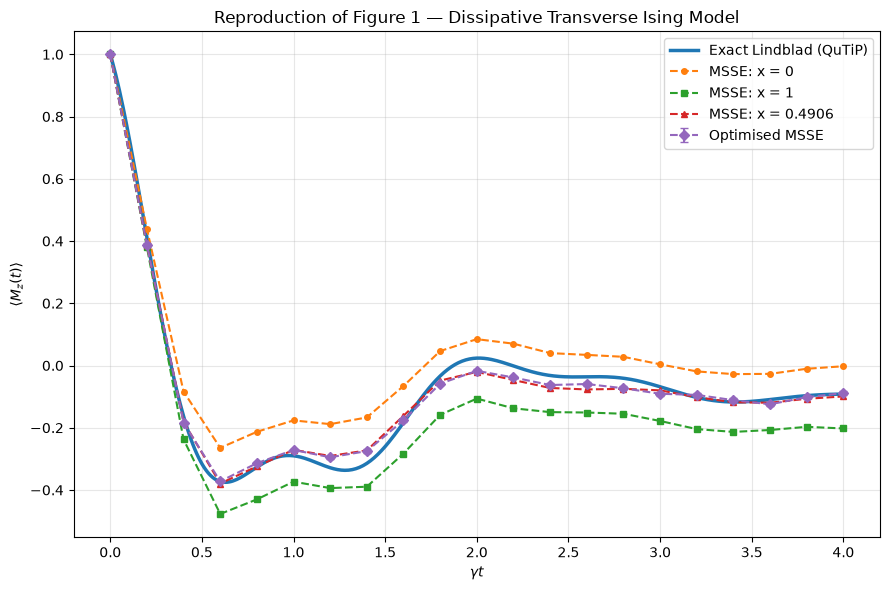

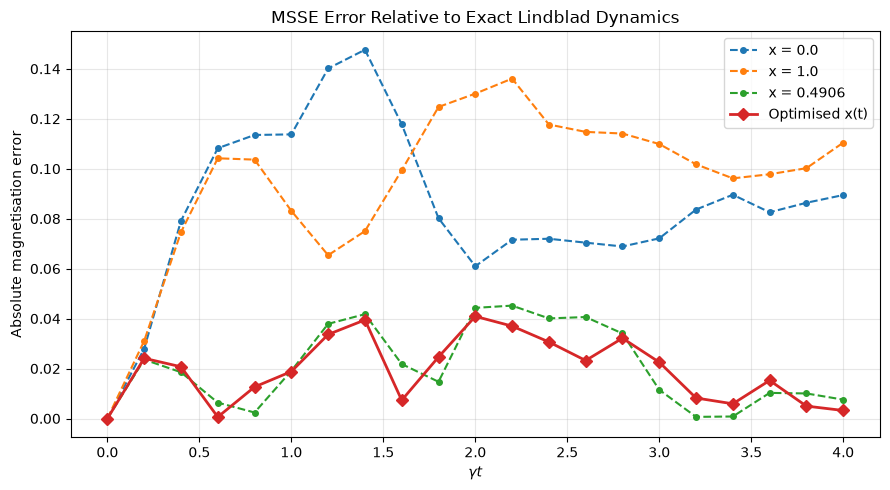


NOTEBOOK 04 VALIDATION SUMMARY
------------------------------
Initial optimal x          : 0.490569
RMSE, x = 0               : 0.090643
RMSE, x = 1               : 0.099840
RMSE, x = 0.4906          : 0.025819
RMSE, optimised x(t)      : 0.023203
Best method               : Optimised x(t)

Notebook 04 complete.


In [6]:
# Exercise 4.6 — Validate and quantify the Figure 1 reproduction

# This exercise uses results already generated in 4.2–4.5:
#
# Mz_exact_sampled
# Mz_exact
# exact_gamma_times
# gamma_times
# results_fixed_x
# fixed_x_values
# Mz_optimised
# Mz_optimised_sem
# x_initial


# ------------------------------------------------------------
# 1. Error metrics
# ------------------------------------------------------------

def calculate_errors(approx, exact):
    """
    Calculate numerical error metrics between an approximate
    magnetisation curve and the exact Lindblad result.
    """

    error = approx - exact

    rmse = np.sqrt(
        np.mean(error**2)
    )

    mae = np.mean(
        np.abs(error)
    )

    max_error = np.max(
        np.abs(error)
    )

    return rmse, mae, max_error


# ------------------------------------------------------------
# 2. Calculate errors for every method
# ------------------------------------------------------------

validation_results = {}


# Fixed-x results
for x in fixed_x_values:

    approx = results_fixed_x[x]["mean"]

    rmse, mae, max_error = calculate_errors(
        approx,
        Mz_exact_sampled
    )

    validation_results[f"x = {x}"] = {
        "rmse": rmse,
        "mae": mae,
        "max_error": max_error
    }


# Optimised result
rmse_opt, mae_opt, max_error_opt = calculate_errors(
    Mz_optimised,
    Mz_exact_sampled
)

validation_results["Optimised x(t)"] = {
    "rmse": rmse_opt,
    "mae": mae_opt,
    "max_error": max_error_opt
}


# ------------------------------------------------------------
# 3. Print quantitative comparison
# ------------------------------------------------------------

print("FIGURE 1 REPRODUCTION — ERROR SUMMARY")
print("-------------------------------------")

print(
    f"{'Method':<20}"
    f"{'RMSE':>12}"
    f"{'MAE':>12}"
    f"{'Max Error':>14}"
)

print("-" * 58)

for method, values in validation_results.items():

    print(
        f"{method:<20}"
        f"{values['rmse']:>12.6f}"
        f"{values['mae']:>12.6f}"
        f"{values['max_error']:>14.6f}"
    )


# ------------------------------------------------------------
# 4. Quantify improvement from optimisation
# ------------------------------------------------------------

rmse_x0 = validation_results["x = 0.0"]["rmse"]
rmse_x1 = validation_results["x = 1.0"]["rmse"]
rmse_x_fixed = validation_results["x = 0.4906"]["rmse"]

improvement_vs_x0 = (
    (rmse_x0 - rmse_opt)
    / rmse_x0
    * 100
)

improvement_vs_x1 = (
    (rmse_x1 - rmse_opt)
    / rmse_x1
    * 100
)

improvement_vs_fixed = (
    (rmse_x_fixed - rmse_opt)
    / rmse_x_fixed
    * 100
)


print("\nOPTIMISATION IMPROVEMENT")
print("------------------------")

print(
    f"Compared with x = 0:      "
    f"{improvement_vs_x0:.2f}%"
)

print(
    f"Compared with x = 1:      "
    f"{improvement_vs_x1:.2f}%"
)

print(
    f"Compared with x = 0.4906: "
    f"{improvement_vs_fixed:.2f}%"
)


# ------------------------------------------------------------
# 5. Check the initial optimisation value
# ------------------------------------------------------------

difference_from_paper = abs(
    x_initial - 0.4906
)

print("\nINITIAL x VALIDATION")
print("--------------------")

print(
    f"Calculated x(0)          = "
    f"{x_initial:.6f}"
)

print(
    f"Paper value              = "
    f"0.490600"
)

print(
    f"Absolute difference      = "
    f"{difference_from_paper:.6e}"
)


# ------------------------------------------------------------
# 6. Identify which method has the smallest RMSE
# ------------------------------------------------------------

best_method = min(
    validation_results,
    key=lambda method:
        validation_results[method]["rmse"]
)

print("\nBEST NUMERICAL AGREEMENT")
print("------------------------")

print(
    f"Lowest-RMSE method = "
    f"{best_method}"
)

print(
    f"Lowest RMSE        = "
    f"{validation_results[best_method]['rmse']:.6f}"
)


# ------------------------------------------------------------
# 7. Final Figure 1-style comparison
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))


# Exact solution
plt.plot(
    exact_gamma_times,
    Mz_exact,
    linewidth=2.5,
    label="Exact Lindblad (QuTiP)"
)


# x = 0
plt.plot(
    gamma_times,
    results_fixed_x[0.0]["mean"],
    marker="o",
    linestyle="--",
    markersize=4,
    label="MSSE: x = 0"
)


# x = 1
plt.plot(
    gamma_times,
    results_fixed_x[1.0]["mean"],
    marker="s",
    linestyle="--",
    markersize=4,
    label="MSSE: x = 1"
)


# x = 0.4906
plt.plot(
    gamma_times,
    results_fixed_x[0.4906]["mean"],
    marker="^",
    linestyle="--",
    markersize=5,
    label="MSSE: x = 0.4906"
)


# Optimised x(t)
plt.errorbar(
    gamma_times,
    Mz_optimised,
    yerr=Mz_optimised_sem,
    marker="D",
    linestyle="--",
    markersize=5,
    capsize=3,
    label="Optimised MSSE"
)


plt.xlabel(
    r"$\gamma t$"
)

plt.ylabel(
    r"$\langle M_z(t)\rangle$"
)

plt.title(
    "Reproduction of Figure 1 — "
    "Dissipative Transverse Ising Model"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 8. Plot absolute error versus time
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))


for x in fixed_x_values:

    absolute_error = np.abs(
        results_fixed_x[x]["mean"]
        - Mz_exact_sampled
    )

    plt.plot(
        gamma_times,
        absolute_error,
        marker="o",
        linestyle="--",
        markersize=4,
        label=f"x = {x}"
    )


optimised_absolute_error = np.abs(
    Mz_optimised
    - Mz_exact_sampled
)

plt.plot(
    gamma_times,
    optimised_absolute_error,
    marker="D",
    linewidth=2,
    label="Optimised x(t)"
)


plt.xlabel(
    r"$\gamma t$"
)

plt.ylabel(
    "Absolute magnetisation error"
)

plt.title(
    "MSSE Error Relative to Exact Lindblad Dynamics"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 9. Final notebook validation summary
# ------------------------------------------------------------

print("\nNOTEBOOK 04 VALIDATION SUMMARY")
print("------------------------------")

print(
    f"Initial optimal x          : "
    f"{x_initial:.6f}"
)

print(
    f"RMSE, x = 0               : "
    f"{rmse_x0:.6f}"
)

print(
    f"RMSE, x = 1               : "
    f"{rmse_x1:.6f}"
)

print(
    f"RMSE, x = 0.4906          : "
    f"{rmse_x_fixed:.6f}"
)

print(
    f"RMSE, optimised x(t)      : "
    f"{rmse_opt:.6f}"
)

print(
    f"Best method               : "
    f"{best_method}"
)

print(
    "\nNotebook 04 complete."
)

In [7]:
# Export Notebook 04 results for use in Notebook 05

from pathlib import Path

data_dir = Path("../data")
data_dir.mkdir(exist_ok=True)

np.savez(
    data_dir / "notebook04_results.npz",

    gamma_times=gamma_times,

    exact_mz=Mz_exact_sampled,

    fixed_04906_mz=
        results_fixed_x[0.4906]["mean"],

    optimised_mz=
        Mz_optimised,

    optimised_sem=
        Mz_optimised_sem
)

print(
    "Notebook 04 results saved to:",
    data_dir / "notebook04_results.npz"
)

Notebook 04 results saved to: ..\data\notebook04_results.npz
